# Estudio dqdv y ajustes sobre 10°C


In [ ]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl


✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [74]:
import numpy as np
import pandas as pd
from importlib import reload
from datetime import datetime, timedelta, timezone

In [9]:
# --- carga de datos ---
path_json = "../tmp/NMC-10-cada3.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())

Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 67


## Gráficos para observar dataset

In [10]:
# --- Selección de ciclos ---
ciclos_sel_todos = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    #rango=(21, 900),
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 66 ciclos seleccionados
   → [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]


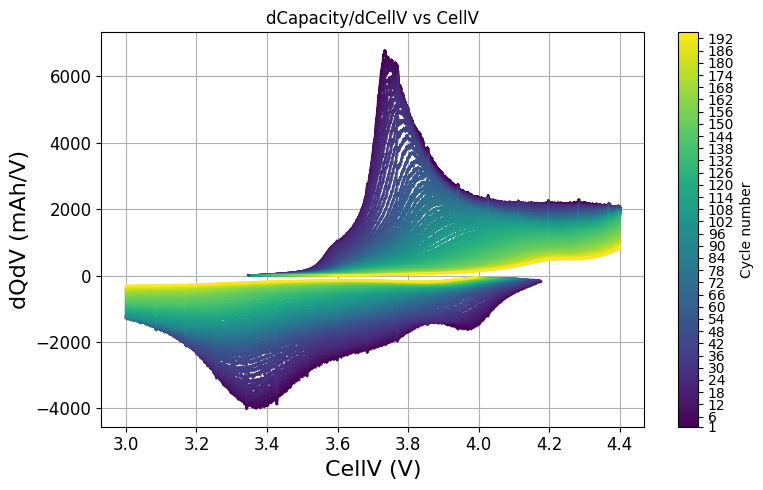

In [11]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos, dict_ciclos_sep)


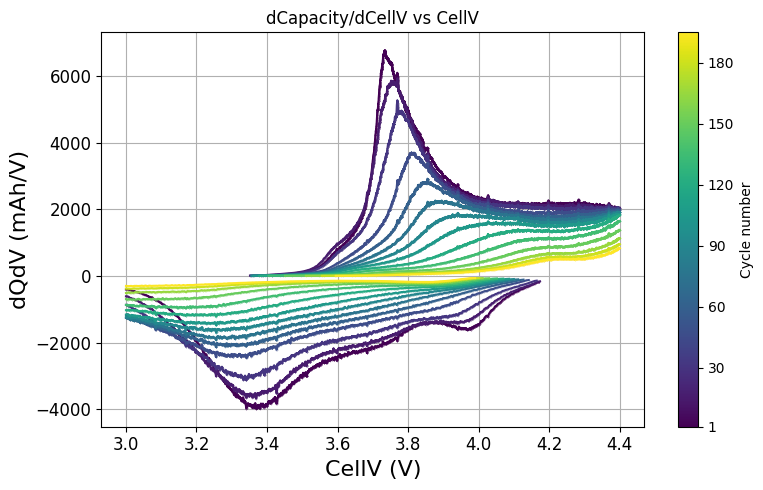

In [12]:
ciclos_sel_grafico = [ciclos_sel_todos[i] for i in range(len(ciclos_sel_todos)) if i % 5 == 0]

pl.plot_n_cycles_dqdv(ciclos_sel_grafico, dict_ciclos_sep)

Gráfico: salto promedio de voltaje (ΔV) entre puntos consecutivos. Resolución (r=1/ΔV) normalizada al ciclo de mayor resolución.


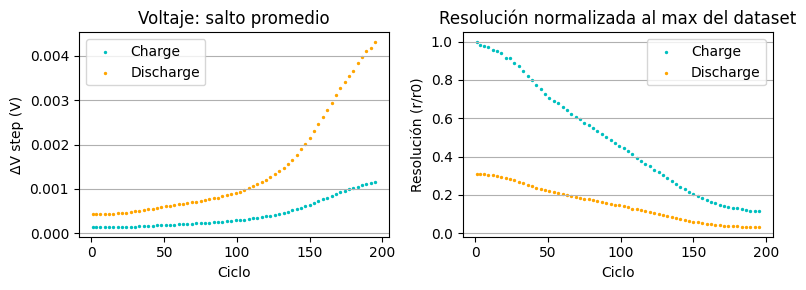

Puntos promedio por ventana de 2 mV:


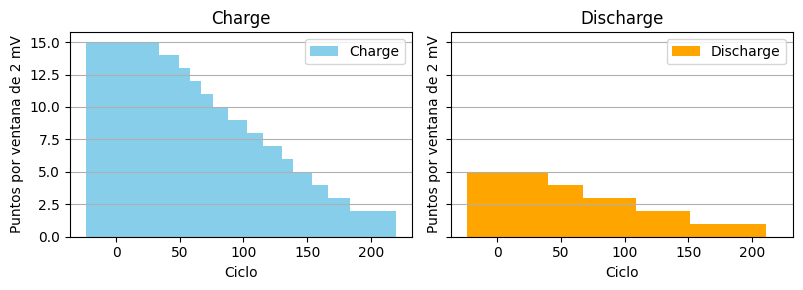

In [22]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel_todos, dict_ciclos_sep)

#utl.resolucion_Q(ciclos_sel_todos, dict_ciclos_sep)

## Pruebo parametros filtros para calcular derivada

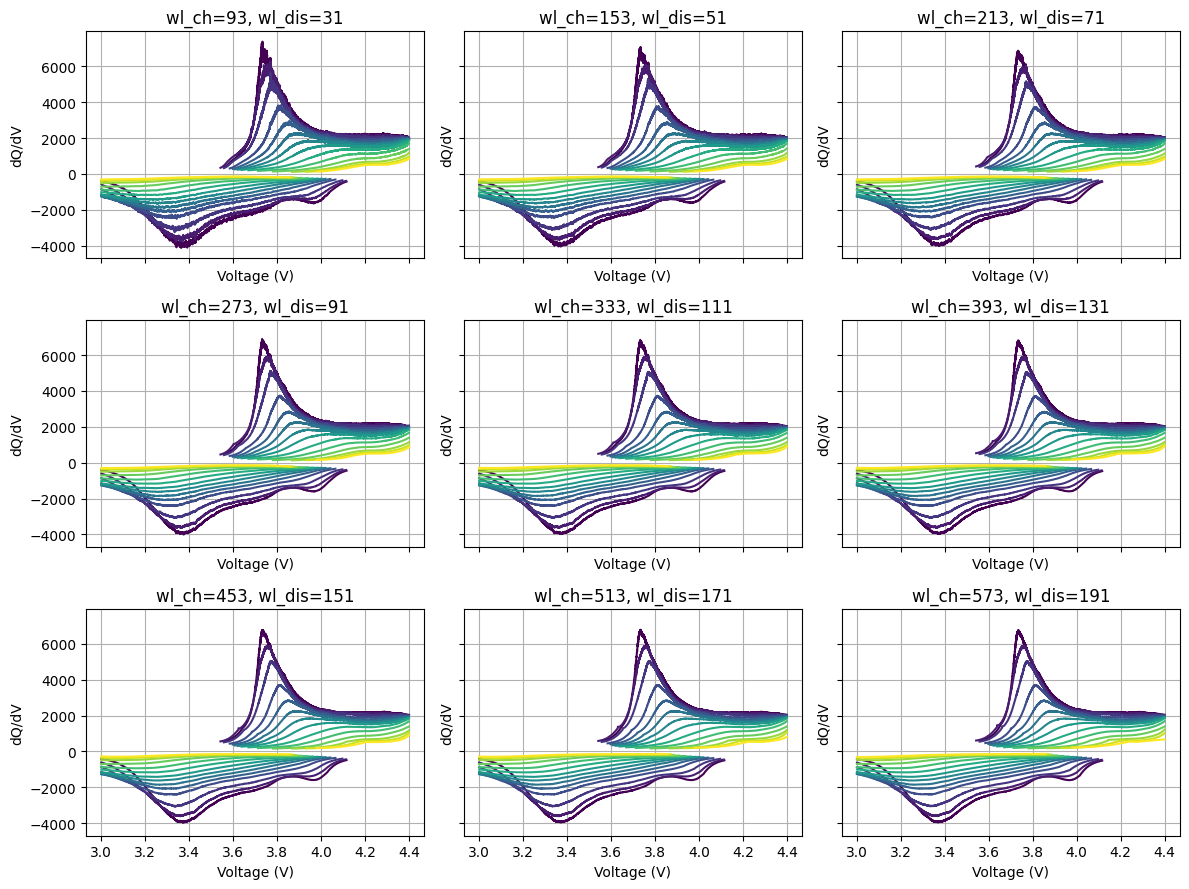

In [24]:
dr.plot_dqdv_muchos_wl(ciclos_sel_grafico, dict_ciclos_sep, wl_values=[31,51,71,91,111,131,151,171,191], truncar_values=(20,60))

## Calculo derivada con los parámetros dados

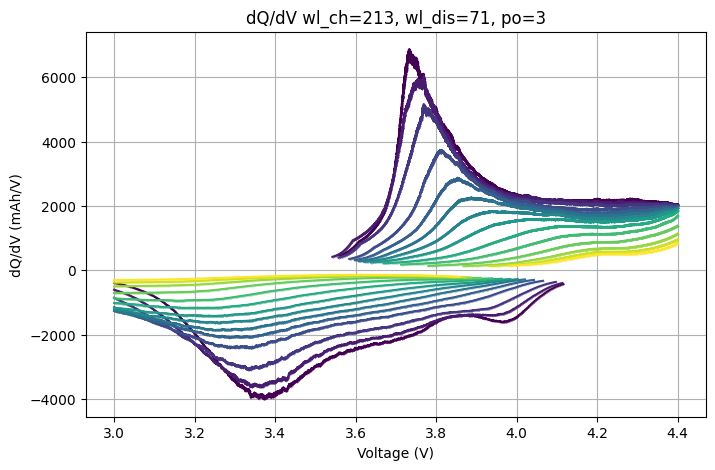

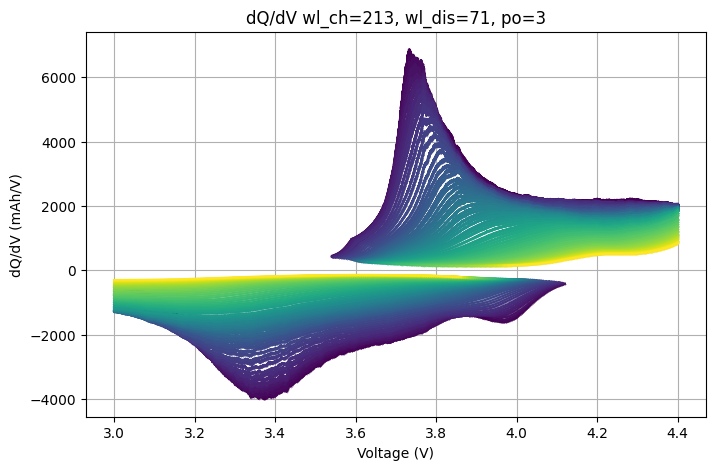

In [25]:
# --- Trunco datos y calculo derivada ---


# --- Parámetros para el cálculo de la derivada ---
# En este conjunto de datos, la señal de carga tiene 3 veces mas resolución que la de descarga.
# Estos valores pueden cambiar según el dataset.

# Para NMC-20:
#   charge (wl = 153, truncar los n=30 puntos iniciales)
#   discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

# Para NMC-10:
#   charge (wl = 213, truncar los n=30 puntos iniciales)
#   discharge (wl = 71 = 153 / 3, truncar los n=10=30/3 puntos finales)



# --- Calculo derivada dQdV ---
diccio = dict_ciclos_sep
diccio = dr.truncar_señal(ciclos_sel_grafico, dict_ciclos_sep, n_dis=20, n_ch=60)
diccio =  dr.plot_dqdV(ciclos_sel_grafico, diccio, wl_dis=71, wl_ch=213)

diccio_todos = dr.truncar_señal(ciclos_sel_todos, dict_ciclos_sep, n_dis=20, n_ch=60)
diccio_todos =  dr.plot_dqdV(ciclos_sel_todos, diccio_todos, wl_dis=71, wl_ch=213)

# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

# AJUSTES

In [ ]:
# Indices de ciclos disponibles (todos):
# [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]

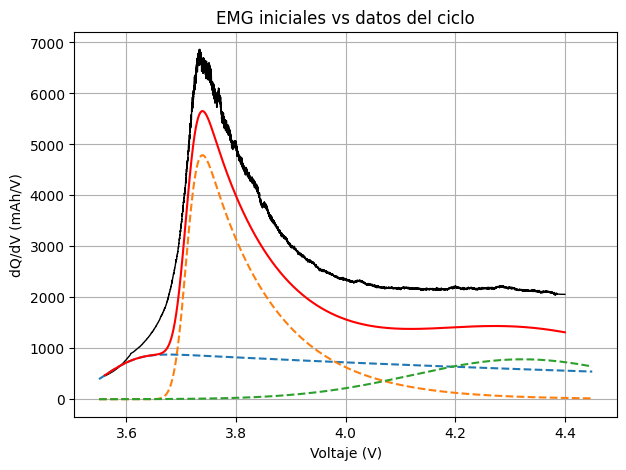

In [71]:
# --- Pruebo manualmente guess inicial para parametros de ajuste ---

# En la EMG los parámetros son: (amplitud, media, sigma, lambda)

df_ch = diccio_todos[1]['Ch']

param_guess = [(1500, 3.56, 5.15620917e-02, 6.37474532e-01),
                ( 7.95488829e+02, 3.71021028e+00, 1.75009098e-02, 8.04841702e+00),
                #(2.12087703e+02, 3.99801493e+00, 2.48713898e-02, 5.36805383e-01),
                (3.95158095e+02, 4.30488376e+00, 2.00453430e-01, 5.51398592e+01)
                ]

ft.plot_emg_guess(df_ch, param_guess, x_range=(3.55, 4.45),legend=False)

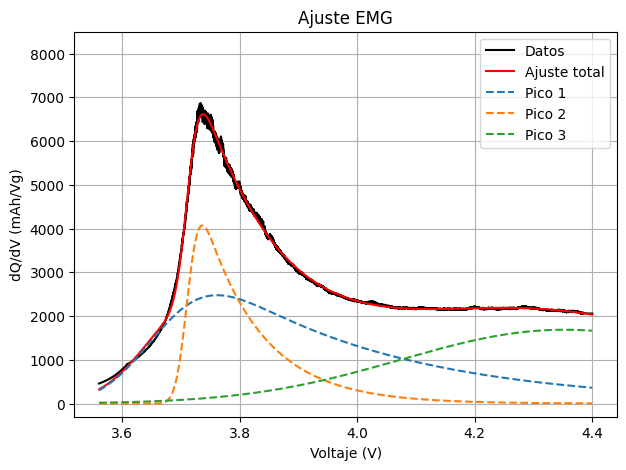

Parámetros optimizados ciclo 1 carga:
[1.18755445e+03 3.66000000e+00 7.35838350e-02 3.22069806e+00
 5.50463062e+02 3.71184186e+00 1.56909614e-02 1.01915550e+01
 1.24528665e+03 4.20488376e+00 2.44991919e-01 5.07773895e+00]


In [73]:
# --- Test de ajuste del primer ciclo ---

# Parámetros iniciales por pico
# Formato: (amplitud, media, sigma, lambda)
p_ini_peaks = [(2.55731493e+03, 3.61000000e+00, 5.16592298e-02, 7.74918978e-01),
                (7.88127408e+02, 3.71032062e+00, 1.77322114e-02, 8.22465006e+00),
                #(2.12087703e+02, 3.99801493e+00, 2.48713898e-02, 5.36805383e-01),
                (5.22420960e+02, 4.25488376e+00, 1.98977731e-01, 1.17940762e+01)
                ]

n_peaks = len(p_ini_peaks)

# Construir p_ini_emg y bounds automáticamente
p_ini_emg = []
lb, ub = [], []

for a0, mu0, sigma0, lam0 in p_ini_peaks:
    p_ini_emg += [a0, mu0, sigma0, lam0]
    lb += [0, mu0-0.05, 1e-6, 0]
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]

bounds_emg = (lb, ub)

# Ajuste del ciclo 1 de carga
df_ch_1 = diccio[1]['Ch']
p_opt_1, cov_1 = ft.fit_emg_ciclo(df_ch_1, p_ini_emg, bounds_emg)
ft.plot_emg_fit(df_ch_1, p_opt_1)

print("Parámetros optimizados ciclo 1 carga:")
print(p_opt_1)

## Loop

In [75]:
timestamp = datetime.now(timezone(timedelta(hours=-3))).strftime("%Y-%m-%d_%H-%M-%S")

In [ ]:
# --- Ajuste de múltiples ciclos ---

# ---- Elegir ciclos del loop, nombre del .csv, parámetros iniciales y bounds ------------------
nombre = f'NMC10C_EMG_{timestamp}'
ciclos_ajustar = [c for c in ciclos_sel_todos] #if 0 <= c <= 900]
ciclos_graficar = [c for c in ciclos_ajustar if c == 1 or c % 10 == 0]

# Elegir p_ini (son los parametros iniciales del primer ajuste)
param_guess = [(1500, 3.56, 5.15620917e-02, 6.37474532e-01),
                ( 7.95488829e+02, 3.71021028e+00, 1.75009098e-02, 8.04841702e+00),
                #(2.12087703e+02, 3.99801493e+00, 2.48713898e-02, 5.36805383e-01),
                (3.95158095e+02, 4.30488376e+00, 2.00453430e-01, 5.51398592e+01)
                ]
p_ini_emg = [x for t in param_guess for x in t]  # aplanado

# Elegir bounds_ini manualmente (son los bounds del primer ajuste)
lb, ub = [], []
for (a0, mu0, sigma0, lam0) in param_guess:
    lb += [0.9*a0, 0.9*mu0, 0.9*sigma0, 0.9*lam0]
    ub += [1.1*a0, 1.1*mu0, 1.1*sigma0, 1.1*lam0]
bounds_ini_emg = (lb, ub)

# Elegir bounds del loop (son los bounds del resto de los ajustes)
cfg_bounds = {
    'perc_a': 0.1,
    'perc_mu': 0.1,
    'perc_sigma': 0.1,
    'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}
}
# ----------------------------------------------------------------------------------------------

parametros, covs = ft.fitloop_emg(
    diccio,
    ciclos=ciclos_ajustar,
    p_ini_emg=p_ini_emg,
    bounds_ini_emg=bounds_ini_emg,
    ciclos_grafico=ciclos_graficar,
    cfg_bounds=cfg_bounds
)
ft.guardar_parametros_emg(parametros, ciclos_sel_todos, nombre)